# Lab 8: Logistic regression

Preserves model inputs and split. Replaced 0.01-step plot mesh with 250 x 250 grids so raw-band plots fit memory. Color uses color= to avoid ambiguous matplotlib c= handling.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


In [2]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:

dataset = pd.read_csv('Liss_III.csv')
X = dataset.iloc[:, [1, 2]].values
Y = dataset.iloc[:, 5].values
print(X)
print(Y)

[[ 72  56]
 [ 66  53]
 [ 86  72]
 [ 73  58]
 [ 72  56]
 [ 63  48]
 [ 69  56]
 [ 74  67]
 [ 65  50]
 [ 66  50]
 [ 69  55]
 [ 69  53]
 [ 80  68]
 [ 69  55]
 [ 65  50]
 [ 64  49]
 [ 77  65]
 [ 89  74]
 [ 65  51]
 [ 72  57]
 [ 81  68]
 [ 76  59]
 [105  95]
 [ 77  63]
 [ 73  61]
 [ 70  54]
 [ 65  48]
 [ 72  58]
 [ 80  66]
 [ 84  75]
 [ 74  58]
 [ 73  57]
 [ 64  49]
 [ 91  74]
 [ 70  53]
 [ 91  75]
 [ 72  56]
 [ 70  57]
 [ 69  54]
 [ 72  56]
 [ 63  48]
 [ 71  55]
 [ 67  50]
 [ 67  50]
 [ 56  40]
 [ 66  50]
 [ 70  55]
 [ 71  56]
 [ 79  62]
 [ 80  66]
 [ 80  67]
 [ 78  65]
 [ 68  51]
 [ 70  58]
 [ 78  65]
 [ 70  59]
 [ 65  52]
 [ 87  78]
 [ 72  58]
 [ 68  56]
 [ 73  60]
 [ 70  56]
 [ 85  72]
 [ 79  63]
 [ 79  64]
 [ 74  60]
 [ 84  72]
 [ 76  63]
 [ 75  62]
 [ 71  58]
 [ 72  58]
 [ 69  51]
 [ 88  74]
 [ 75  62]
 [ 72  57]
 [ 91  81]
 [ 70  56]
 [ 66  51]
 [ 69  55]
 [ 67  50]
 [ 74  58]
 [ 70  53]
 [ 76  62]
 [ 76  68]
 [ 72  62]
 [ 74  60]
 [ 74  57]
 [ 70  53]
 [ 66  50]
 [ 67  51]
 [ 65  50]

In [4]:

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [5]:

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:

Y_pred = classifier.predict(X_test)
print(Y_pred)


[1 2 2 1 2 1 1 2 1 2 1 1 1 2 1 1 2 1 1 1 1 2 1 2 1 2 1 1 2 1 1 2 2 2 1 1 1
 1 1 2 1 2 1 1 2 1 2 2 1 2 2 1 2 1 2 2 1 1 2 1 1 2 1 2 1 2 1 2 1 2 1 2 1 1
 1 1 2 2 2 2 2 1 1 1 2 2 1 2 1 2 2 2 1 1 1 1 1 2 2 2]


In [7]:

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[52  2]
 [ 3 43]]


In [8]:
print(Y_test)
print(len(Y_test))

[1 2 2 1 2 1 1 2 1 2 1 1 1 2 1 1 2 1 2 2 1 2 1 2 1 2 1 1 2 1 1 2 2 2 1 1 1
 1 1 2 1 2 1 1 2 1 2 2 1 2 2 1 2 1 2 2 1 1 1 1 1 2 1 2 1 2 1 1 1 2 1 2 1 1
 1 1 2 2 2 2 2 1 1 1 2 2 1 2 2 2 2 2 1 1 1 1 1 2 2 2]
100


In [9]:
Error=Y_pred-Y_test
OA = (cm[0,0]+cm[1,1])/len(Y_test)*100
print('OA :',OA,'%')

OA : 95.0 %


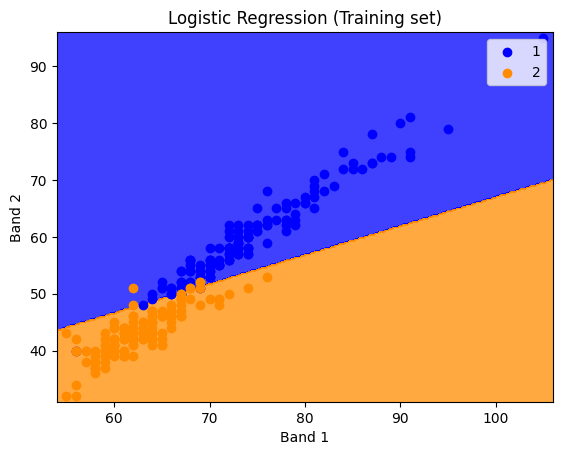

In [11]:

from matplotlib.colors import ListedColormap
X_set, Y_set = X_train, Y_train
X1, X2 = np.meshgrid(np.linspace(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 250),
                     np.linspace(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 250))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('blue', 'darkorange')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_set)):
    plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],
                color = ListedColormap(('blue', 'darkorange'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Band 1')
plt.ylabel('Band 2')
plt.legend()
plt.show()

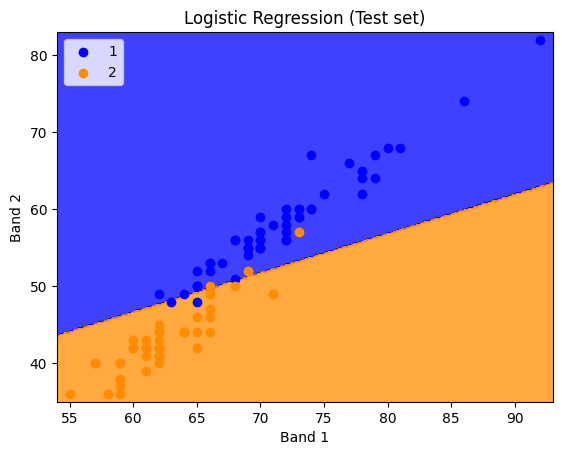

In [12]:

from matplotlib.colors import ListedColormap
X_set, Y_set = X_test, Y_test
X1, X2 = np.meshgrid(np.linspace(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 250),
                     np.linspace(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 250))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('blue', 'darkorange')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_set)):
    plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],
                color = ListedColormap(('blue', 'darkorange'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Band 1')
plt.ylabel('Band 2')
plt.legend()
plt.show()

              precision    recall  f1-score   support

           1       0.95      0.96      0.95        54
           2       0.96      0.93      0.95        46

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



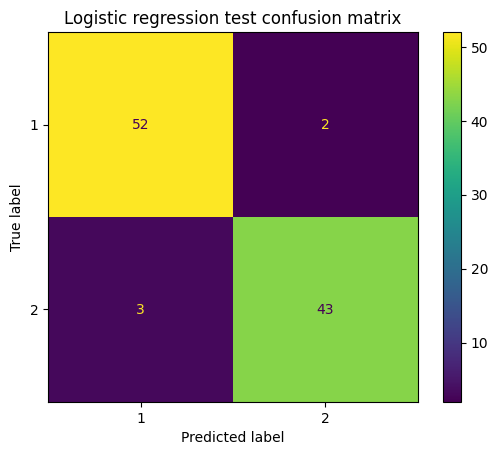

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(Y_test,Y_pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred);plt.title('Logistic regression test confusion matrix');plt.show()